# Latency code

This notebook generates the plots for Supplementary Figure 11. All plots use the retinal model trained for prediction. The pre-trained model can either be downloaded from this repo or can be trained from scatch (see README).

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.abspath(".") if os.path.exists("setup.py") else os.path.abspath("..")

## Spike latency

In [3]:
def plot_spike_code(spike_code, v_min, v_max, cmap, ax):
    
    def nicify(ax):
        ax.set_xticks([])
        ax.set_yticks([])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
    
    def add_bar(im, ax):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("bottom", size="4%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
        cbar.ax.tick_params(labelsize=35) 
        cbar.outline.set_linewidth(3)
        cbar.ax.tick_params(width=3)
        
        return cbar
    
    im = ax.imshow(spike_code, vmin=v_min, vmax=v_max, cmap=cmap)
    nicify(ax)
    
    return add_bar(im, ax)

In [4]:
larva_sequence = analysis.get_larva_sequence(root)
latency_query = analysis.LatencyQuery(root, larva_sequence, pred_offset=128)
rel_latency_code = latency_query.to_relative_latency_code(36).cpu()
rate_code = latency_query.to_rate_code().cpu()

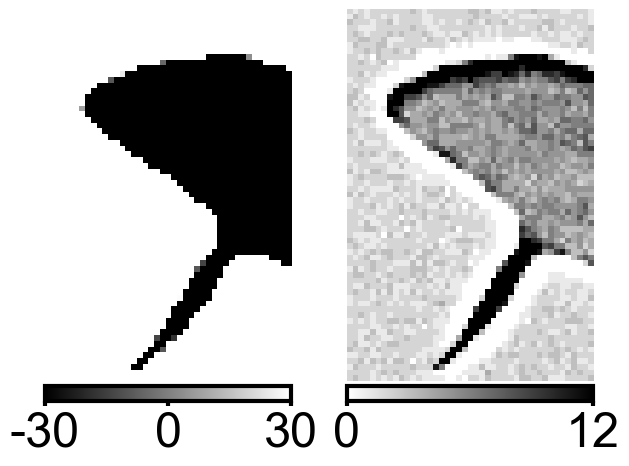

In [5]:
fig, ax = plt.subplots(1, 2)
n = 133

cbar = plot_spike_code(rel_latency_code[0, n], -7, 7, "gray", ax[0])
cbar.set_ticks([-7, 0, 7])
cbar.set_ticklabels(["-30", "0", "30"])
cbar = plot_spike_code(rate_code[0, n], 0, 12, "gray_r", ax[1])
cbar.set_ticks([0, 12])
cbar.set_ticklabels(["0", "12"])
fig.tight_layout()
plt.savefig(f"{root}/figures/supp/single_cell_spike_decoding.svg", format="svg", transparent=False, bbox_inches="tight")